<a href="https://colab.research.google.com/github/mashan275/data-science-2024/blob/main/Pertemuan3_Hasta_satriya_240401010207.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LOAD DATASET

Shape awal: (130, 7)

5 Data Awal:
   id  luas_m2  harga_juta   kota  kamar  tahun_bangun kondisi
0   1    297.0      1084.0  jogja    2.0          2000    baik
1   2    254.0       761.0  Medan    NaN          1995   Bagus
2   3    249.7       895.0  Depok    NaN          1983    baik
3   4     49.7       178.0    YGY    5.0          2013    baik
4   5    133.4       424.0  Medan    5.0          2004  Sedang

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            130 non-null    int64  
 1   luas_m2       112 non-null    float64
 2   harga_juta    113 non-null    float64
 3   kota          130 non-null    object 
 4   kamar         120 non-null    float64
 5   tahun_bangun  130 non-null    int64  
 6   kondisi       130 non-null    object 
dtypes: float64(3), int64(2), object(2)
memory usage: 7.2+ KB
None


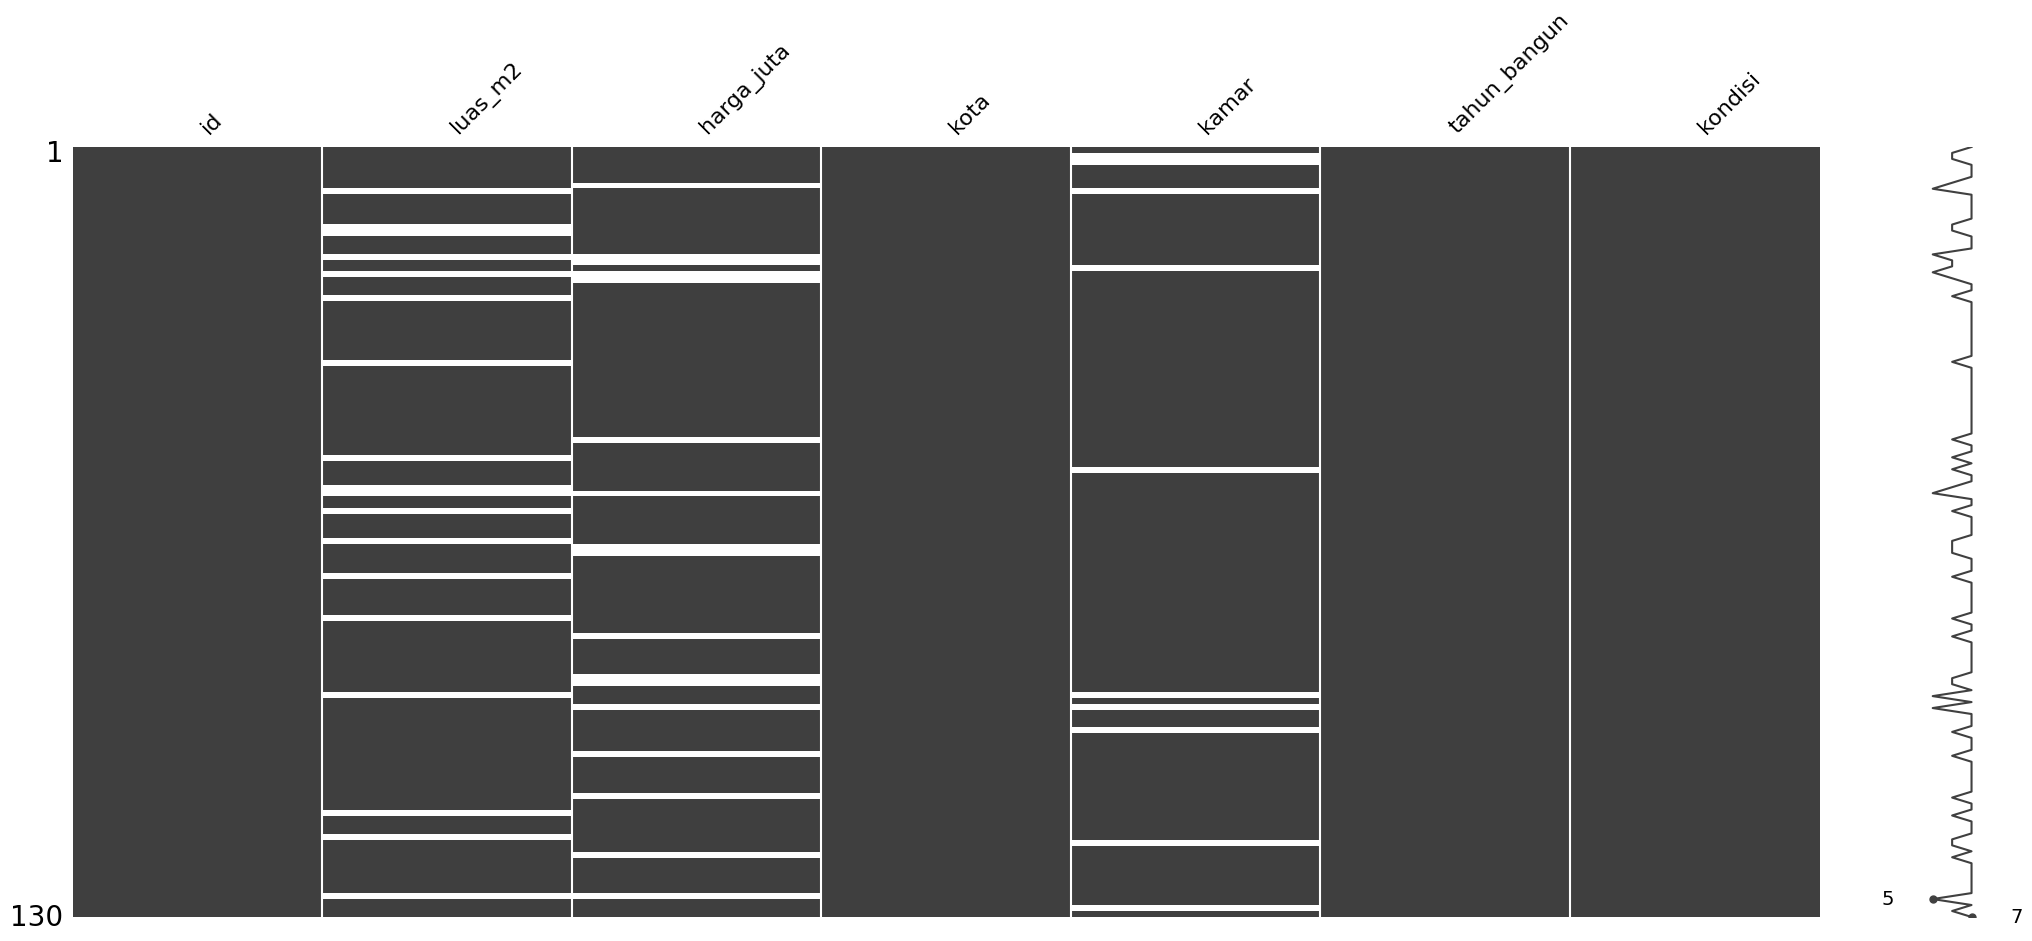

In [20]:
# =========================================================
# DATA CLEANING PIPELINE LENGKAP
# Pertemuan 3 - Pengantar Data Science
# =========================================================

# =========================
# IMPORT LIBRARY
# =========================
import pandas as pd
import numpy as np
import json
import requests

from scipy import stats
from scipy.stats.mstats import winsorize
from sklearn.impute import KNNImputer
from pandas import json_normalize

# Optional visualisasi missing value
# pip install missingno
try:
    import missingno as msno
    HAS_MISSINGNO = True
except:
    HAS_MISSINGNO = False

# =========================================================
# STEP 1 - LOAD DATASET
# =========================================================

print("=" * 60)
print("LOAD DATASET")
print("=" * 60)

# Ganti sesuai lokasi file
df = pd.read_csv("housing_dirty.csv")

print("\nShape awal:", df.shape)

print("\n5 Data Awal:")
print(df.head())

print("\nInfo Dataset:")
print(df.info())

print("\nDeskripsi Statistik:")
print(df.describe())

# =========================================================
# STEP 2 - DETEKSI MISSING VALUE
# =========================================================

print("\n" + "=" * 60)
print("DETEKSI MISSING VALUE")
print("=" * 60)

missing_count = df.isnull().sum()

print("\nJumlah Missing Value:")
print(missing_count)

missing_pct = (
    df.isnull().sum() / len(df) * 100
).round(2)

print("\nPersentase Missing Value:")
print(missing_pct[missing_pct > 0])

# Baris yang semua nilainya kosong
all_missing = df[df.isnull().all(axis=1)]

print("\nBaris semua missing:", len(all_missing))

# Drop kolom jika missing > 40%
threshold = 0.4

cols_drop = df.columns[
    df.isnull().mean() > threshold
]

if len(cols_drop) > 0:
    print("\nKolom dihapus:", list(cols_drop))
    df.drop(columns=cols_drop, inplace=True)

# Visualisasi missing value
if HAS_MISSINGNO:
    print("\nVisualisasi missing value tersedia")
    msno.matrix(df)

# =========================================================
# STEP 3 - HAPUS DUPLIKAT
# =========================================================

print("\n" + "=" * 60)
print("HAPUS DUPLIKAT")
print("=" * 60)

n_dup = df.duplicated().sum()

print("\nJumlah duplikat:", n_dup)

# Tampilkan data duplikat
df_dup = df[df.duplicated(keep=False)]

if len(df_dup) > 0:
    print("\nContoh data duplikat:")
    print(df_dup.head())

# Hapus duplikat
df.drop_duplicates(inplace=True)

print("\nShape setelah hapus duplikat:", df.shape)

# =========================================================
# STEP 4 - NORMALISASI STRING
# =========================================================

print("\n" + "=" * 60)
print("NORMALISASI STRING")
print("=" * 60)

# Normalisasi kota
if 'kota' in df.columns:
    df['kota'] = (
        df['kota']
        .astype(str)
        .str.strip()
        .str.title()
    )

# Normalisasi kondisi
if 'kondisi' in df.columns:
    df['kondisi'] = (
        df['kondisi']
        .astype(str)
        .str.strip()
        .str.lower()
    )

print("\nNormalisasi string selesai")

# =========================================================
# STEP 5 - IMPUTASI MISSING VALUE
# =========================================================

print("\n" + "=" * 60)
print("IMPUTASI MISSING VALUE")
print("=" * 60)

# Median untuk numerik
numerik_cols = df.select_dtypes(
    include='number'
).columns

for col in numerik_cols:

    if df[col].isnull().sum() > 0:

        median_val = df[col].median()

        df[col] = df[col].fillna(median_val)

        print(f"{col} -> imputasi median")

# Modus untuk kategorik
kategori_cols = df.select_dtypes(
    include='object'
).columns

for col in kategori_cols:

    if df[col].isnull().sum() > 0:

        mode_val = df[col].mode()[0]

        df[col] = df[col].fillna(mode_val)

        print(f"{col} -> imputasi modus")

print("\nSisa missing value:")
print(df.isnull().sum())

# =========================================================
# STEP 6 - KNN IMPUTER (OPSIONAL)
# =========================================================

print("\n" + "=" * 60)
print("KNN IMPUTER")
print("=" * 60)

try:

    knn_cols = list(numerik_cols)

    knn = KNNImputer(n_neighbors=5)

    df[knn_cols] = knn.fit_transform(df[knn_cols])

    print("KNN Imputer berhasil")

except Exception as e:

    print("KNN gagal:", e)

# =========================================================
# STEP 7 - DETEKSI OUTLIER IQR
# =========================================================

print("\n" + "=" * 60)
print("DETEKSI OUTLIER IQR")
print("=" * 60)

def deteksi_outlier_iqr(df, kolom):

    Q1 = df[kolom].quantile(0.25)
    Q3 = df[kolom].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[kolom] < lower) |
        (df[kolom] > upper)
    ]

    return lower, upper, outliers

# Kolom target
target_outlier = [
    'harga_juta',
    'luas_m2',
    'tahun_bangun'
]

for col in target_outlier:

    if col in df.columns:

        lower, upper, out_df = deteksi_outlier_iqr(
            df,
            col
        )

        print(f"\nKolom: {col}")
        print(f"Jumlah outlier: {len(out_df)}")
        print(f"Batas bawah: {lower}")
        print(f"Batas atas : {upper}")

# =========================================================
# STEP 8 - WINSORIZATION / CAPPING
# =========================================================

print("\n" + "=" * 60)
print("WINSORIZATION")
print("=" * 60)

for col in target_outlier:

    if col in df.columns:

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df[col] = df[col].clip(
            lower=lower,
            upper=upper
        )

        print(f"{col} berhasil dicapping")

# =========================================================
# STEP 9 - DETEKSI OUTLIER Z-SCORE
# =========================================================

print("\n" + "=" * 60)
print("OUTLIER Z-SCORE")
print("=" * 60)

try:

    z_scores = np.abs(
        stats.zscore(df[numerik_cols])
    )

    outlier_mask = (z_scores > 3).any(axis=1)

    print(
        "Jumlah outlier Z-score:",
        outlier_mask.sum()
    )

except Exception as e:

    print("Z-score gagal:", e)

# =========================================================
# STEP 10 - VALIDASI DATA
# =========================================================

print("\n" + "=" * 60)
print("VALIDASI DATA")
print("=" * 60)

print("\nTotal Missing Value:")
print(df.isnull().sum().sum())

print("\nTotal Duplikat:")
print(df.duplicated().sum())

print("\nShape akhir:")
print(df.shape)

# =========================================================
# STEP 11 - EXPORT CSV
# =========================================================

print("\n" + "=" * 60)
print("EXPORT DATA")
print("=" * 60)

df.to_csv(
    "housing_clean.csv",
    index=False
)

print("\nDataset bersih berhasil disimpan")
print("Nama file: housing_clean.csv")

# =========================================================
# STEP 12 - MEMBACA JSON LOKAL
# =========================================================

print("\n" + "=" * 60)
print("MEMBACA JSON")
print("=" * 60)

try:

    with open(
        "data/produk.json",
        encoding="utf-8"
    ) as f:

        data = json.load(f)

    df_json = pd.DataFrame(data)

    print("\nJSON berhasil dibaca")
    print(df_json.head())

except Exception as e:

    print("JSON tidak ditemukan:", e)

# =========================================================
# STEP 13 - AKSES REST API
# =========================================================

print("\n" + "=" * 60)
print("AKSES REST API")
print("=" * 60)

try:

    URL = "https://jsonplaceholder.typicode.com/users"

    response = requests.get(
        URL,
        timeout=10
    )

    if response.status_code == 200:

        data = response.json()

        df_api = json_normalize(
            data,
            sep='_'
        )

        print("\nData API berhasil diambil")

        kolom_tampil = [
            'id',
            'name',
            'email',
            'address_city'
        ]

        print(df_api[kolom_tampil])

    else:

        print(
            "Error status:",
            response.status_code
        )

except Exception as e:

    print("Gagal akses API:", e)

# =========================================================
# STEP 14 - PARAMETER API
# =========================================================

print("\n" + "=" * 60)
print("API DENGAN PARAMETER")
print("=" * 60)

try:

    params = {
        'userId': 1
    }

    posts = requests.get(
        "https://jsonplaceholder.typicode.com/posts",
        params=params,
        timeout=10
    ).json()

    df_posts = pd.DataFrame(posts)

    print(df_posts.head())

except Exception as e:

    print("Gagal request parameter:", e)

# =========================================================
# SELESAI
# =========================================================

print("\n" + "=" * 60)
print("SEMUA PROSES DATA CLEANING SELESAI")
print("=" * 60)